In [ ]:
'''
Name: Ramita Rathore
CSC 6740: Data Mining

Project: Wine Quality Assessment using Data Mining Techniques – Phase 3 Complete Project

Goal: Build a multi-class classifier for wine quality using physicochemical features.

Target:
- Low quality: quality < 5
- Medium quality: 5 <= quality <= 6
- High quality: quality > 6

Dataset Citation:

P. Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis.
Modeling wine preferences by data mining from physicochemical properties.
In Decision Support Systems, Elsevier, 47(4):547-553. ISSN: 0167-9236.

'''

'\nName:\nCSC 6740: Data Mining\n\nProject: Wine Quality Assessment using Data Mining Techniques – Phase 3 Complete Project\n\nGoal: Build a multi-class classifier for wine quality using physicochemical features.\n\nTarget:\n- Low quality: quality < 5\n- Medium quality: 5 <= quality <= 6\n- High quality: quality > 6\n\nDataset Citation:\n\nP. Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis.\nModeling wine preferences by data mining from physicochemical properties.\nIn Decision Support Systems, Elsevier, 47(4):547-553. ISSN: 0167-9236.\n\n'

In [ ]:
# ----- Imports -----

import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

standardScaler = StandardScaler()

In [ ]:
# Set notebook seed
seed = 42

In [ ]:
# ----- Dataset Ingestion -----

# To simulate the paper, the comparison will be done on red and wine datasets seperately
red_df = pd.read_csv('winequality-red.csv', sep=';')
white_df = pd.read_csv('winequality-white.csv', sep=';')


# Check ingested files
print('\nRed wine info:')
print(red_df.info())
print('\n White wine info:')
print(white_df.info())


# Red wine instances: 1599 --> Matches dataset
red_instances = len(red_df)
print('\nRed wine instances: ', red_instances)
# White wine instances: 4898 --> Matches dataset
white_instances = len(white_df)
print('\nWhie wine instances: ', white_instances)

# Total instances: 6497
print('\nTotal instances: ', red_instances + white_instances)


Red wine info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None

 White wine info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns

Red wine quality relative frequency:
quality
3    0.006254
4    0.033146
5    0.425891
6    0.398999
7    0.124453
8    0.011257
Name: proportion, dtype: float64
White wine quality relative frequency:
quality
3    0.004083
4    0.033279
5    0.297468
6    0.448755
7    0.179665
8    0.035729
9    0.001021
Name: proportion, dtype: float64




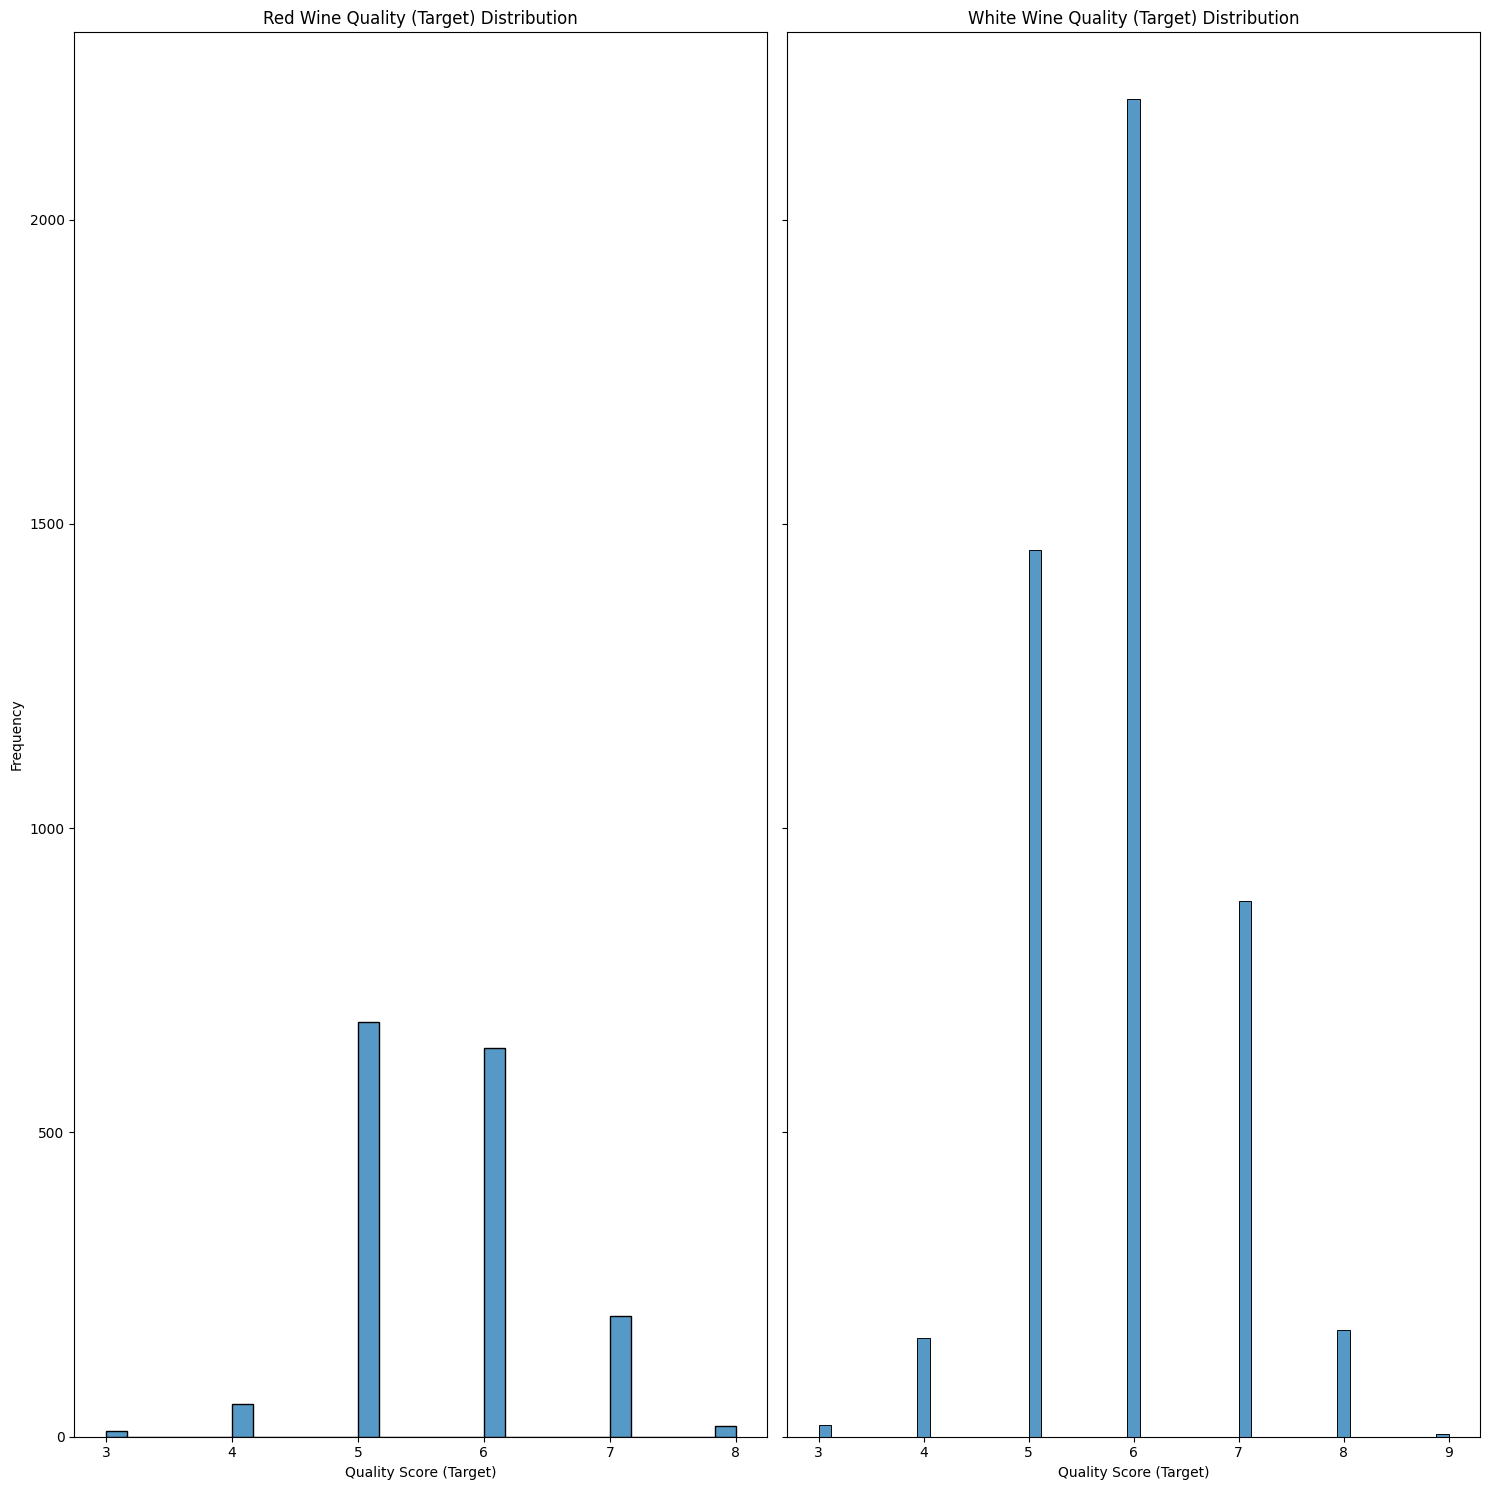

In [ ]:
# ----- Dataset Preprocessing -----


# The file 'winequality.names' mentions that the data is not balanced
# There are more normal wines, than really bad (0) or really good ones(10)

# Checking class imbalance
print('Red wine quality relative frequency:')
print(red_df['quality'].value_counts(normalize=True).sort_index())

print('White wine quality relative frequency:')
print(white_df['quality'].value_counts(normalize=True).sort_index())
print('\n')

# Plot class imbalance
fig, axes = plt.subplots(1,2, figsize=(15,15), sharey=True)

sns.histplot(x='quality', data=red_df, ax=axes[0])
axes[0].set_title('Red Wine Quality (Target) Distribution')
axes[0].set_xlabel('Quality Score (Target)')
axes[0].set_ylabel('Frequency')

sns.histplot(x='quality', data=white_df, ax=axes[1])
axes[1].set_title('White Wine Quality (Target) Distribution')
axes[1].set_xlabel('Quality Score (Target)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
# ----- Dataset Preprocessing -----

'''
Analysis:
Most of the data is concentrated in the 5-6 score range in both the red and white wine dataset.
Thus, there is a class imbalance where more wines are considered normal rather than on extreme ends (bad quality or great quality).

Thus, I will split the wine quality class into 3 way splits.
Low: quality < 5
Medium: 5 <= quality <= 6
High: quality > 6
'''

'\nAnalysis:\nMost of the data is concentrated in the 5-6 score range in both the red and white wine dataset.\nThus, there is a class imbalance where more wines are considered normal rather than on extreme ends (bad quality or great quality).\n\nThus, I will split the wine quality class into 3 way splits.\nLow: quality < 5\nMedium: 5 <= quality <= 6\nHigh: quality > 6\n'

In [ ]:
# ----- Dataset Preprocessing -----

# Convert the wine quality label into 3 way split class labels
# Mapping = Low: quality < 5, Medium: 5 <= quality <= 6, High: quality > 6
# Mapping = Low: 0, Medium: 1, High: 2
def map_three_split(quality_score):
  if quality_score < 5:
    return 0 # Low
  elif quality_score < 7:
    return 1 # Medium
  else:
    return 2 # High

# Apply mapping
red_df['quality_3class'] = red_df['quality'].apply(map_three_split)
white_df['quality_3class'] = white_df['quality'].apply(map_three_split)

In [ ]:
# ----- Dataset Preprocessing -----

# Check dataframe info
print('\nRed wine info:')
print(red_df.info())
print('\n White wine info:')
print(white_df.info())


Red wine info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
 12  quality_3class        1599 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 162.5 KB
None

 White wine info:
<class 'pandas.core.frame.DataFrame

In [ ]:
# ----- Dataset Preprocessing -----

# The updated quality target label has been successfully added to the dataframe
# Safely, drop the orginal quality target class label

red_df = red_df.drop(columns='quality')
white_df = white_df.drop(columns='quality')

In [ ]:
# ----- Dataset Preprocessing -----

# Check dataframe info, after dropping quality label
print('\nRed wine info:')
print(red_df.info())
print('\n White wine info:')
print(white_df.info())


Red wine info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality_3class        1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None

 White wine info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns

Red wine quality relative frequency:
quality_3class
0    0.039400
1    0.824891
2    0.135710
Name: proportion, dtype: float64
White wine quality relative frequency:
quality_3class
0    0.037362
1    0.746223
2    0.216415
Name: proportion, dtype: float64




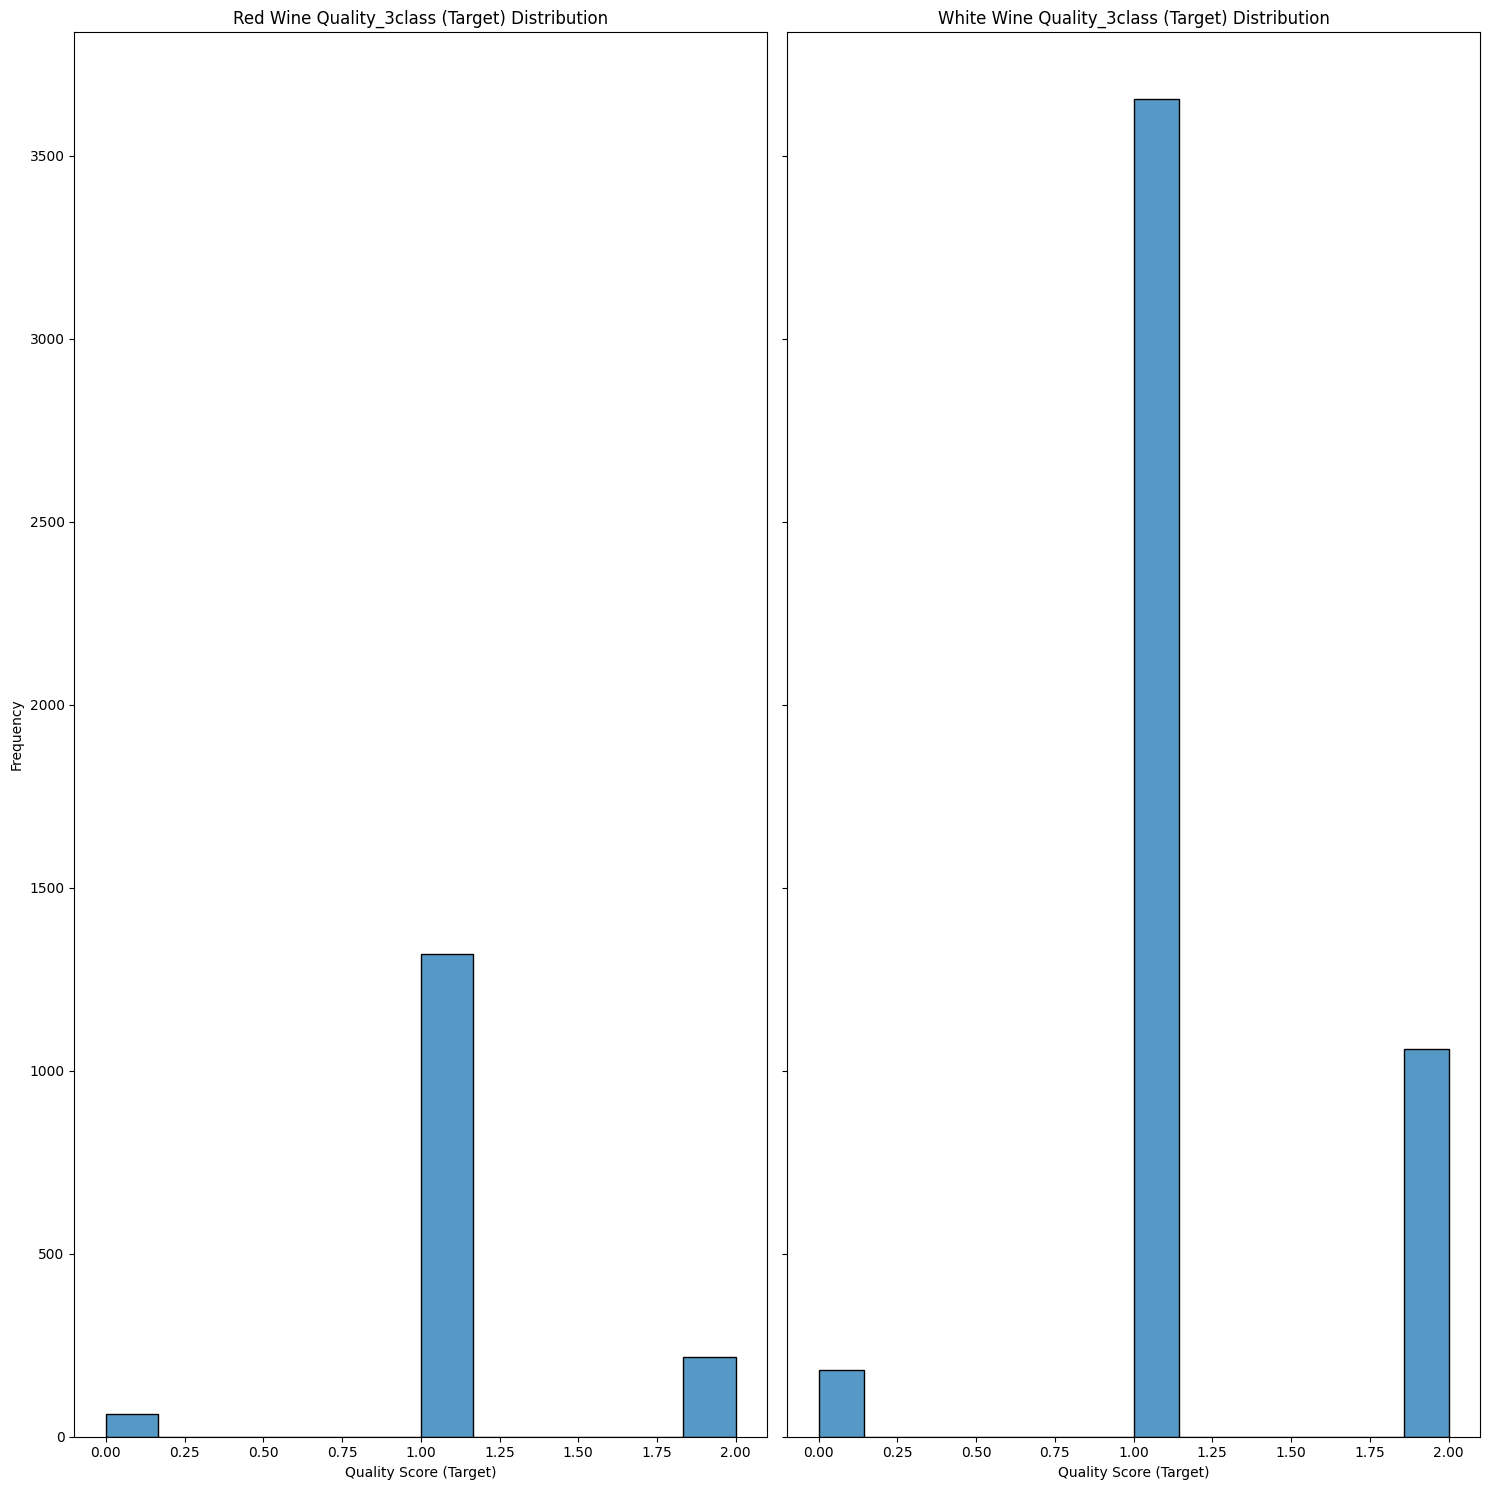

In [ ]:
# ----- Dataset Preprocessing -----

# Checking class imbalance with the new quality class labels
print('Red wine quality relative frequency:')
print(red_df['quality_3class'].value_counts(normalize=True).sort_index())

print('White wine quality relative frequency:')
print(white_df['quality_3class'].value_counts(normalize=True).sort_index())
print('\n')

# Plot class imbalance
fig, axes = plt.subplots(1,2, figsize=(15,15), sharey=True)

sns.histplot(x='quality_3class', data=red_df, ax=axes[0])
axes[0].set_title('Red Wine Quality_3class (Target) Distribution')
axes[0].set_xlabel('Quality Score (Target)')
axes[0].set_ylabel('Frequency')

sns.histplot(x='quality_3class', data=white_df, ax=axes[1])
axes[1].set_title('White Wine Quality_3class (Target) Distribution')
axes[1].set_xlabel('Quality Score (Target)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
# ----- Dataset Preprocessing -----

# Column names
all_column_names = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide',
                    'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality_3class']

# Keep only feature columns
# Remove target column, quality_3class
feature_cols = all_column_names[:-1]

# Keep the target col
target_col = all_column_names[-1]


In [ ]:
# ----- Dataset preprocessing -----

# Red wine training/testing data
X_red = red_df[feature_cols] # Training data
Y_red = red_df[target_col] # Target data

# White wine training/testing data
X_white = white_df[feature_cols]
Y_white = white_df[target_col]


print("Red wine feature instances: ", X_red.shape)
print("\nRed wine target instances: ", Y_red.shape)

print("\nWhite wine feature instances: ", X_white.shape)
print("\nWhite wine target instances: ", Y_white.shape)

Red wine feature instances:  (1599, 11)

Red wine target instances:  (1599,)

White wine feature instances:  (4898, 11)

White wine target instances:  (4898,)


In [ ]:
# ----- Dataset preprocessing -----

# Use stratified train/test splits for similar class proportions

# Red wine
X_red_train, X_red_test, Y_red_train, Y_red_test = train_test_split(
    X_red,
    Y_red,
    test_size=0.40, # Use 40% of data for testing
    train_size=0.60, # Use 60% of data for training
    stratify=Y_red,
    random_state=seed
    )

# White wine
X_white_train, X_white_test, Y_white_train, Y_white_test = train_test_split(
    X_white,
    Y_white,
    test_size=0.40,
    train_size=0.60,
    stratify=Y_white,
    random_state=seed
    )

# Check correct split
print("X_red_train instances: ", X_red_train.shape)
print("Y_red_train instances: ", Y_red_train.shape)

print("X_red_test instances: ", X_red_test.shape)
print("Y_red_test instances: ", Y_red_test.shape)

print("X_white_train instances: ", X_white_train.shape)
print("Y_white_train instances: ", Y_white_train.shape)

print("X_white_test instances: ", X_white_test.shape)
print("Y_white_test instances: ", Y_white_test.shape)



X_red_train instances:  (959, 11)
Y_red_train instances:  (959,)
X_red_test instances:  (640, 11)
Y_red_test instances:  (640,)
X_white_train instances:  (2938, 11)
Y_white_train instances:  (2938,)
X_white_test instances:  (1960, 11)
Y_white_test instances:  (1960,)


In [ ]:
# ----- Classification Modeling -----
## ----- Baseline Modeling -----

# Model pipeline for both datasets
# Feature scaling: StandardScaler()
# Feature reduction technique: Principal Component Analysis (PCA)
# Baseline model: Logistic Regression

red_logreg_pipe = Pipeline([
                        ('scaler', StandardScaler()),
                        ('pca', PCA(n_components=0.95)),
                        ('smote', SMOTE(random_state=seed)),
                        ('logreg', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=seed))
                      ])

white_logreg_pipe = Pipeline([
                        ('scaler', StandardScaler()),
                        ('pca', PCA(n_components=0.95)),
                        ('smote', SMOTE(random_state=seed)),
                        ('logreg', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=seed))
                      ])

In [ ]:
# ----- Classification Modeling -----
## ----- Baseline Modeling -----

# Define cross validator for k-fold
# Ensure correct splits inside GridSearchCV
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Parameter grid
# Tune logistic regression with GridSearchCV on the training data
# Refit the best model automatically
logreg_param_grid = {
    'pca__n_components': [0.90, 0.95, 0.99],
    'smote__k_neighbors':[3,5],
    'logreg__C': [0.01, 0.1, 1, 10, 100],
    'logreg__solver': ['lbfgs']
}

# GridSearchCV
red_logreg_grid = GridSearchCV(
    estimator=red_logreg_pipe,
    param_grid=logreg_param_grid,
    scoring='balanced_accuracy',
    cv=cv,
    refit=True
)

white_logreg_grid = GridSearchCV(
    estimator=white_logreg_pipe,
    param_grid=logreg_param_grid,
    scoring='balanced_accuracy',
    cv=cv,
    refit=True
)

# Fit best model
# Get best parameters
red_logreg_grid.fit(X_red_train, Y_red_train)
white_logreg_grid.fit(X_white_train, Y_white_train)

print('Best parameters for red wine: ', red_logreg_grid.best_params_)
print('Best parameter score for red wine: ', red_logreg_grid.best_score_)

print('Best parameters for white wine: ', white_logreg_grid.best_params_)
print('Best parameter score for white wine: ', white_logreg_grid.best_score_)


Best parameters for red wine:  {'logreg__C': 0.01, 'logreg__solver': 'lbfgs', 'pca__n_components': 0.95, 'smote__k_neighbors': 5}
Best parameter score for red wine:  0.6222240778678129
Best parameters for white wine:  {'logreg__C': 0.01, 'logreg__solver': 'lbfgs', 'pca__n_components': 0.9, 'smote__k_neighbors': 5}
Best parameter score for white wine:  0.6342465047509599


In [ ]:
# ----- Classification Modeling -----
## ----- Baseline Modeling -----

# Predict on the test data
Y_red_test_pred_logreg = red_logreg_grid.predict(X_red_test)
Y_white_test_pred_logreg = white_logreg_grid.predict(X_white_test)

Loadings:
                           PC1       PC2       PC3       PC4       PC5  \
fixed acidity         0.866411 -0.138287 -0.142383 -0.251228 -0.113097   
volatile acidity     -0.394929  0.407526 -0.574208  0.089685  0.125079   
citric acid           0.806303 -0.278059  0.295341 -0.065077 -0.022094   
residual sugar        0.278714  0.297252  0.007574 -0.341212  0.788847   
chlorides             0.385707  0.210545 -0.107445  0.743148  0.135385   
free sulfur dioxide  -0.066786  0.657476  0.614648 -0.103606 -0.089754   
total sulfur dioxide  0.038450  0.751154  0.500552 -0.075517 -0.155911   
density               0.712772  0.340636 -0.404829 -0.147287  0.174819   
pH                   -0.760063 -0.008762  0.033718  0.072118  0.337423   
sulphates             0.405707 -0.070765  0.369508  0.594815  0.251555   
alcohol              -0.229166 -0.589890  0.506801 -0.124282  0.336360   

                           PC6       PC7       PC8       PC9  
fixed acidity        -0.030305  0.2789

Text(0.5, 1.0, 'Red Wine: Features Importance in PCA')

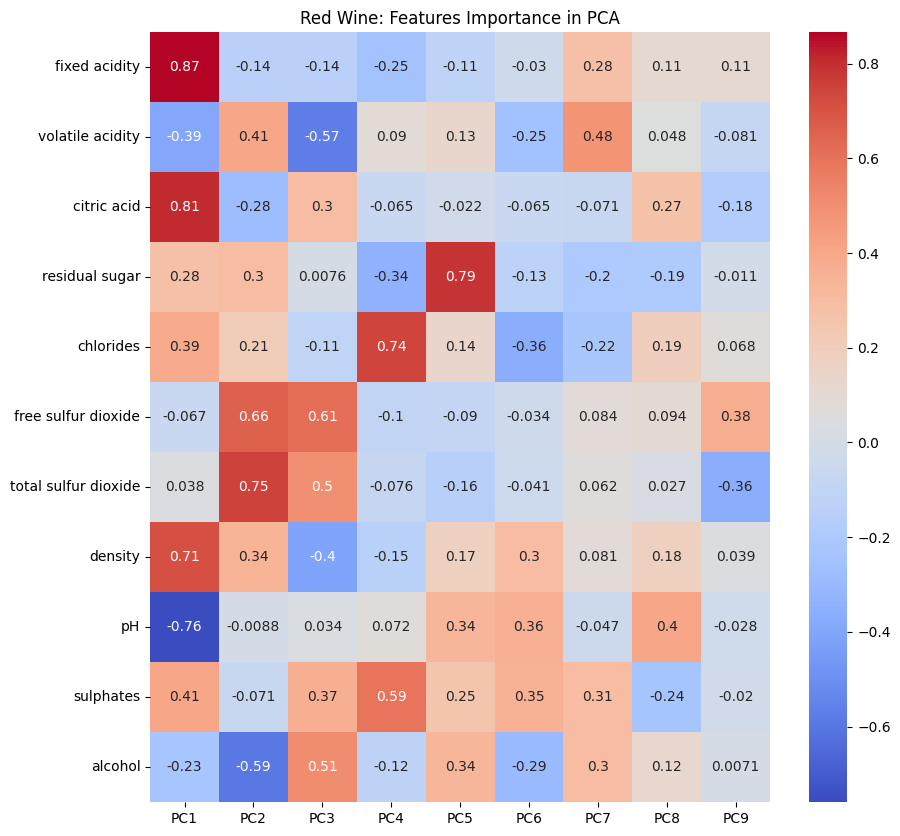

In [ ]:
# ----- Classification Modeling -----
## ----- Baseline Modeling -----
### ----- Evaluation -----

# Check which features are the most important in PCA

# Red Wine
pca_red = red_logreg_grid.best_estimator_.named_steps['pca']

# Compute PCA loadings matrix
loadings_red = pca_red.components_.T * np.sqrt(pca_red.explained_variance_)

# Convert loadings matrix into a dataframe
loadings_red_df = pd.DataFrame(
                              loadings_red,
                              index=feature_cols,
                              columns=[f'PC{i+1}' for i in range(pca_red.n_components_)]
                              )

print('Loadings:')
print(loadings_red_df)

plt.figure(figsize=(10,10))
sns.heatmap(loadings_red_df, annot=True, cmap='coolwarm')
plt.title('Red Wine: Features Importance in PCA')



Loadings:
                           PC1       PC2       PC3       PC4       PC5  \
fixed acidity         0.269160 -0.728325 -0.159400  0.044699  0.237771   
volatile acidity     -0.014363  0.038216  0.684961  0.303038  0.570849   
citric acid           0.238310 -0.434837 -0.583574  0.163928  0.032085   
residual sugar        0.758116  0.009154  0.230722 -0.316877 -0.049778   
chlorides             0.367803 -0.040789  0.151717  0.698016 -0.291164   
free sulfur dioxide   0.533320  0.372010 -0.309291 -0.224874  0.352470   
total sulfur dioxide  0.731305  0.312842 -0.124137  0.000214  0.348903   
density               0.925859 -0.000119  0.128922 -0.062151 -0.166189   
pH                   -0.220403  0.737788 -0.157701  0.068237 -0.206254   
sulphates             0.091101  0.308904 -0.401911  0.501128  0.234912   
alcohol              -0.795841 -0.019690 -0.124803 -0.104864  0.345223   

                           PC6       PC7       PC8  
fixed acidity         0.169467 -0.224820  0.4211

Text(0.5, 1.0, 'White Wine: Features Importance in PCA')

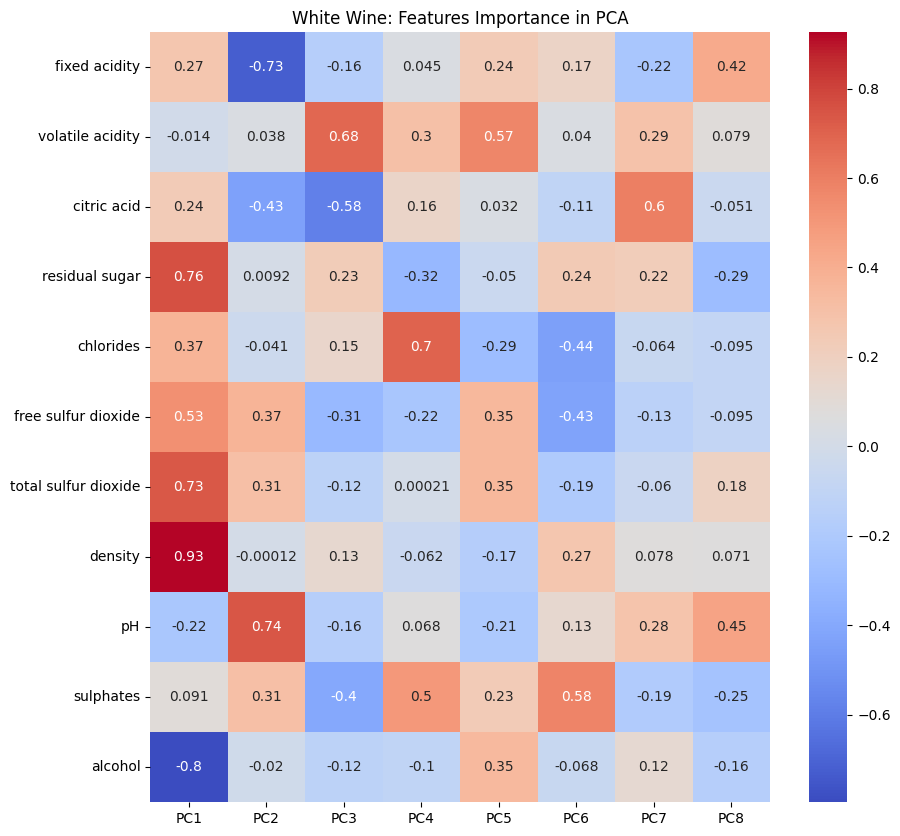

In [ ]:
# ----- Classification Modeling -----
## ----- Baseline Modeling -----
### ----- Evaluation -----

# Check which features are the most important in PCA

# White Wine
pca_white = white_logreg_grid.best_estimator_.named_steps['pca']

# Compute PCA loadings matrix
loadings_white = pca_white.components_.T * np.sqrt(pca_white.explained_variance_)

# Convert loadings matrix into a dataframe
loadings_white_df = pd.DataFrame(
                              loadings_white,
                              index=feature_cols,
                              columns=[f'PC{i+1}' for i in range(pca_white.n_components_)]
                              )

print('Loadings:')
print(loadings_white_df)

plt.figure(figsize=(10,10))
sns.heatmap(loadings_white_df, annot=True, cmap='coolwarm')
plt.title('White Wine: Features Importance in PCA')


In [ ]:
# ----- Classification Modeling -----
## ----- Baseline Modeling -----
### ----- Evaluation -----

# Accuracy, F1-Score, and Classification Report

print("\nRed Wine Evaluation:")

acc_red = accuracy_score(Y_red_test, Y_red_test_pred_logreg)
balanced_acc_red = balanced_accuracy_score(Y_red_test, Y_red_test_pred_logreg)
f1_score_macro_red = f1_score(Y_red_test, Y_red_test_pred_logreg, average='macro')
f1_score_weighted_red = f1_score(Y_red_test, Y_red_test_pred_logreg, average='weighted')

classification_report_red = classification_report(
    Y_red_test,
    Y_red_test_pred_logreg,
    target_names=['Low', 'Medium','High'],
    zero_division=0
    )
print('\nModel = Logistic Regression')
print('\nAccuracy = ', acc_red)
print('\nBalanced Accuracy = ', balanced_acc_red)
print('\nMacro F1-Score = ', f1_score_macro_red)
print('\nWeighted F1-Score = ', f1_score_weighted_red)

print('\nClassification Report = \n', (classification_report_red))


print("\nWhite Wine Evaluation:")

acc_white = accuracy_score(Y_white_test, Y_white_test_pred_logreg)
balanced_acc_white = balanced_accuracy_score(Y_white_test, Y_white_test_pred_logreg)
f1_score_macro_white = f1_score(Y_white_test, Y_white_test_pred_logreg, average='macro')
f1_score_weighted_white = f1_score(Y_white_test, Y_white_test_pred_logreg, average='weighted')

classification_report_white = classification_report(
    Y_white_test,
    Y_white_test_pred_logreg,
    target_names=['Low', 'Medium','High'],
    zero_division=0
    )
print('\nModel = Logistic Regression')
print('\nAccuracy = ', acc_white)
print('\nBalanced Accuracy = ', balanced_acc_white)
print('\nMacro F1-Score = ', f1_score_macro_white)
print('\nWeighted F1-Score = ', f1_score_weighted_white)

print('\nClassification Report = \n', (classification_report_white))


Red Wine Evaluation:

Model = Logistic Regression

Accuracy =  0.571875

Balanced Accuracy =  0.69000609543713

Macro F1-Score =  0.46121054350720253

Weighted F1-Score =  0.6368338047076875

Classification Report = 
               precision    recall  f1-score   support

         Low       0.12      0.76      0.20        25
      Medium       0.95      0.53      0.68       528
        High       0.37      0.78      0.50        87

    accuracy                           0.57       640
   macro avg       0.48      0.69      0.46       640
weighted avg       0.84      0.57      0.64       640


White Wine Evaluation:

Model = Logistic Regression

Accuracy =  0.5260204081632653

Balanced Accuracy =  0.5720282622838022

Macro F1-Score =  0.4278925618029666

Weighted F1-Score =  0.5736427201326766

Classification Report = 
               precision    recall  f1-score   support

         Low       0.10      0.55      0.16        73
      Medium       0.86      0.48      0.61      1463
     

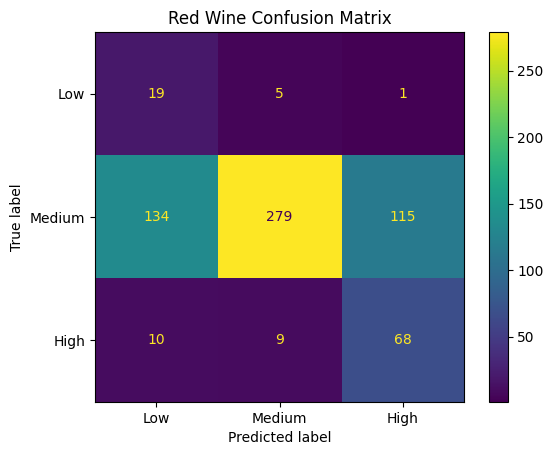

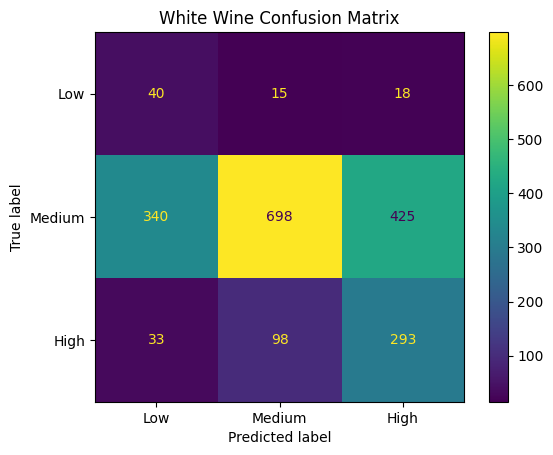

In [ ]:
# ----- Classification Modeling -----
## ----- Baseline Modeling -----
### ----- Evaluation -----

# Confusion Matrices

# Red wine dataset
ConfusionMatrixDisplay.from_predictions(
    Y_red_test,
    Y_red_test_pred_logreg,
    display_labels=['Low', 'Medium','High']
)
plt.title('Red Wine Confusion Matrix')
plt.show()

# White wine dataset
ConfusionMatrixDisplay.from_predictions(
    Y_white_test,
    Y_white_test_pred_logreg,
    display_labels=['Low', 'Medium','High']
)
plt.title('White Wine Confusion Matrix')
plt.show()

Evaluating SVM
Best parameters for red wine:  {'smote__k_neighbors': 3, 'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Best parameter score for red wine:  0.6664546759051136
Best parameters for white wine:  {'smote__k_neighbors': 3, 'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Best parameter score for white wine:  0.6688451380479942

Red Wine Evaluation:

Model = SVM

Accuracy =  0.6359375

Balanced Accuracy =  0.7317920585161964

Macro F1-Score =  0.506768038163387

Weighted F1-Score =  0.6920333463774597

Classification Report = 
               precision    recall  f1-score   support

         Low       0.15      0.80      0.25        25
      Medium       0.96      0.60      0.74       528
        High       0.40      0.79      0.53        87

    accuracy                           0.64       640
   macro avg       0.50      0.73      0.51       640
weighted avg       0.85      0.64      0.69       640


White Wine Evaluation:

Model = SVM

Accuracy =  0.5530

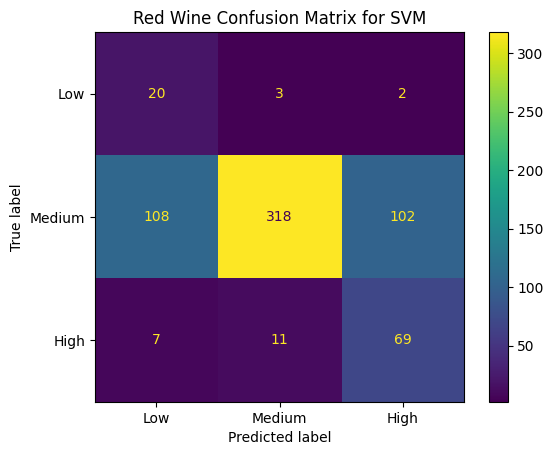

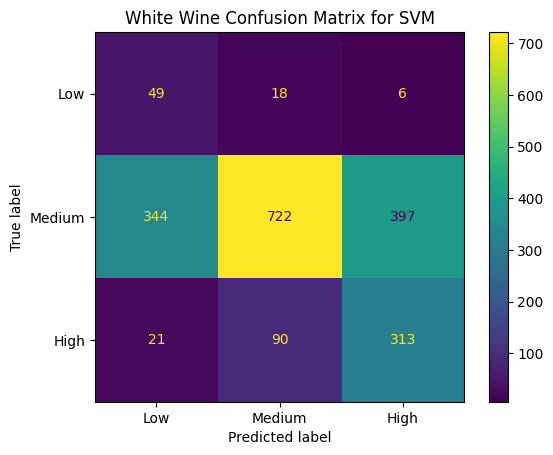

In [ ]:
# ----- Classification Modeling -----
## ----- Stronger Model: Support Vector Machine (SVM) -----


model = 'SVM'
print(f'Evaluating {model}')

# Define cross validator for k-fold
# Ensure correct splits inside GridSearchCV
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Pipelines
red_svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    #('pca', PCA(n_components=0.95)),
    ('smote', SMOTE(random_state=seed)),
    ('svm', SVC(class_weight='balanced', random_state=seed))
])

white_svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    #('pca', PCA(n_components=0.95)),
    ('smote', SMOTE(random_state=seed)),
    ('svm', SVC(class_weight='balanced', random_state=seed))
])

# Parameter grid
svm_param_grid = {
    #'pca__n_components': [0.95],
    'smote__k_neighbors':[3,5],
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 0.01, 0.1, ]
}

# GridSearchCV
red_svm_grid = GridSearchCV(
    estimator=red_svm_pipe,
    param_grid=svm_param_grid,
    scoring='balanced_accuracy',
    cv=cv,
    refit=True,
    n_jobs=-1
)

white_svm_grid = GridSearchCV(
    estimator=white_svm_pipe,
    param_grid=svm_param_grid,
    scoring='balanced_accuracy',
    cv=cv,
    refit=True,
    n_jobs=-1
)

# Fit best model
# Get best parameters
red_svm_grid.fit(X_red_train, Y_red_train)
white_svm_grid.fit(X_white_train, Y_white_train)

print('Best parameters for red wine: ', red_svm_grid.best_params_)
print('Best parameter score for red wine: ', red_svm_grid.best_score_)

print('Best parameters for white wine: ', white_svm_grid.best_params_)
print('Best parameter score for white wine: ', white_svm_grid.best_score_)

# Predict on the test data
Y_red_test_pred_svm = red_svm_grid.predict(X_red_test)
Y_white_test_pred_svm = white_svm_grid.predict(X_white_test)

# Evaluation
print("\nRed Wine Evaluation:")

acc_red = accuracy_score(Y_red_test, Y_red_test_pred_svm)
balanced_acc_red = balanced_accuracy_score(Y_red_test, Y_red_test_pred_svm)
f1_score_macro_red = f1_score(Y_red_test, Y_red_test_pred_svm, average='macro')
f1_score_weighted_red = f1_score(Y_red_test, Y_red_test_pred_svm, average='weighted')

classification_report_red = classification_report(
    Y_red_test,
    Y_red_test_pred_svm,
    target_names=['Low', 'Medium','High'],
    zero_division=0
    )

print(f'\nModel = {model}')
print('\nAccuracy = ', acc_red)
print('\nBalanced Accuracy = ', balanced_acc_red)
print('\nMacro F1-Score = ', f1_score_macro_red)
print('\nWeighted F1-Score = ', f1_score_weighted_red)

print('\nClassification Report = \n', (classification_report_red))


print("\nWhite Wine Evaluation:")

acc_white = accuracy_score(Y_white_test, Y_white_test_pred_svm)
balanced_acc_white = balanced_accuracy_score(Y_white_test, Y_white_test_pred_svm)
f1_score_macro_white = f1_score(Y_white_test, Y_white_test_pred_svm, average='macro')
f1_score_weighted_white = f1_score(Y_white_test, Y_white_test_pred_svm, average='weighted')

classification_report_white = classification_report(
    Y_white_test,
    Y_white_test_pred_svm,
    target_names=['Low', 'Medium','High'],
    zero_division=0
    )
print(f'\nModel = {model}')
print('\nAccuracy = ', acc_white)
print('\nBalanced Accuracy = ', balanced_acc_white)
print('\nMacro F1-Score = ', f1_score_macro_white)
print('\nWeighted F1-Score = ', f1_score_weighted_white)

print('\nClassification Report = \n', (classification_report_white))

# Confusion Matrices

# Red wine dataset
ConfusionMatrixDisplay.from_predictions(
    Y_red_test,
    Y_red_test_pred_svm,
    display_labels=['Low', 'Medium','High']
)
plt.title(f'Red Wine Confusion Matrix for {model}')
plt.show()

# White wine dataset
ConfusionMatrixDisplay.from_predictions(
    Y_white_test,
    Y_white_test_pred_svm,
    display_labels=['Low', 'Medium','High']
)
plt.title(f'White Wine Confusion Matrix for {model}')
plt.show()

Evaluating Random Forest
Best parameters for red wine:  {'rf__max_depth': 10, 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 10, 'rf__n_estimators': 200}
Best parameter score for red wine:  0.5853319111564756
Best parameters for white wine:  {'rf__max_depth': 10, 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 10, 'rf__n_estimators': 300}
Best parameter score for white wine:  0.6357542571429788

Red Wine Evaluation:

Model = Random Forest

Accuracy =  0.821875

Balanced Accuracy =  0.6703962034134449

Macro F1-Score =  0.6181251210802418

Weighted F1-Score =  0.8326804552035523

Classification Report = 
               precision    recall  f1-score   support

         Low       0.29      0.36      0.32        25
      Medium       0.93      0.85      0.89       528
        High       0.54      0.80      0.65        87

    accuracy                           0.82       640
   macro avg       0.59      0.67      0.62       640
weighted avg       0.85      0.82      0.83       640

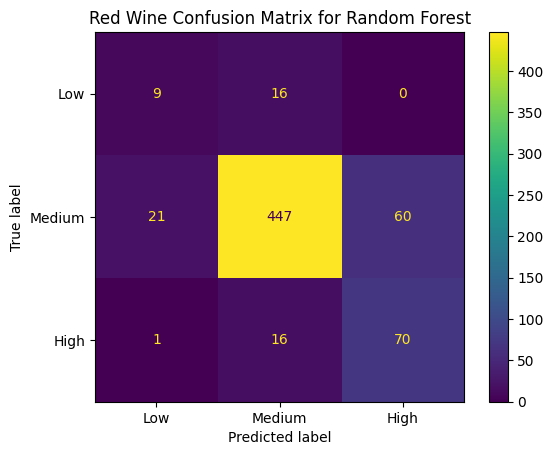

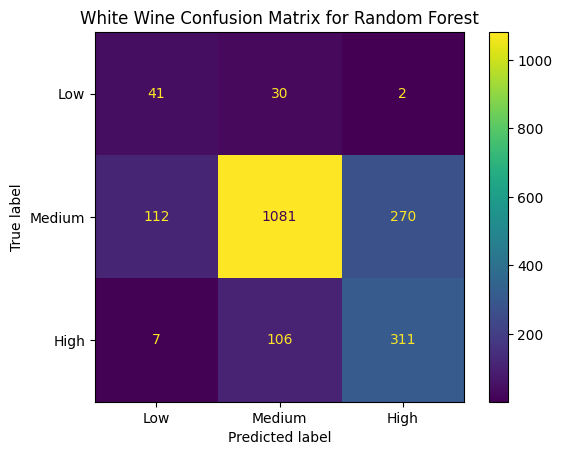

In [ ]:
# ----- Classification Modeling -----
## ----- Stronger Model: Random Forest (RF) -----


model = 'Random Forest'
print(f'Evaluating {model}')

# Define cross validator for k-fold
# Ensure correct splits inside GridSearchCV
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Pipelines
red_rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    #('pca', PCA(n_components=0.95)),
    ('smote', SMOTE(random_state=seed)),
    ('rf', RandomForestClassifier(class_weight='balanced', random_state=seed))
])

white_rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    #('pca', PCA(n_components=0.95)),
    ('smote', SMOTE(random_state=seed)),
    ('rf', RandomForestClassifier(class_weight='balanced', random_state=seed))
])

# Parameter grid
rf_param_grid = {
    #'pca__n_components': [0.90, 0.95, 0.99],
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [None, 10,20,30],
    'rf__min_samples_split': [2,5,10],
    'rf__min_samples_leaf': [1,2,4]
}

# GridSearchCV
red_rf_grid = GridSearchCV(
    estimator=red_rf_pipe,
    param_grid=rf_param_grid,
    scoring='balanced_accuracy',
    cv=cv,
    refit=True,
    n_jobs=-1
)

white_rf_grid = GridSearchCV(
    estimator=white_rf_pipe,
    param_grid=rf_param_grid,
    scoring='balanced_accuracy',
    cv=cv,
    refit=True,
    n_jobs=-1
)

# Fit best model
# Get best parameters
red_rf_grid.fit(X_red_train, Y_red_train)
white_rf_grid.fit(X_white_train, Y_white_train)

print('Best parameters for red wine: ', red_rf_grid.best_params_)
print('Best parameter score for red wine: ', red_rf_grid.best_score_)

print('Best parameters for white wine: ', white_rf_grid.best_params_)
print('Best parameter score for white wine: ', white_rf_grid.best_score_)

# Predict on the test data
Y_red_test_pred_rf = red_rf_grid.predict(X_red_test)
Y_white_test_pred_rf = white_rf_grid.predict(X_white_test)

# Evaluation
print("\nRed Wine Evaluation:")

acc_red = accuracy_score(Y_red_test, Y_red_test_pred_rf)
balanced_acc_red = balanced_accuracy_score(Y_red_test, Y_red_test_pred_rf)
f1_score_macro_red = f1_score(Y_red_test, Y_red_test_pred_rf, average='macro')
f1_score_weighted_red = f1_score(Y_red_test, Y_red_test_pred_rf, average='weighted')

classification_report_red = classification_report(
    Y_red_test,
    Y_red_test_pred_rf,
    target_names=['Low', 'Medium','High'],
    zero_division=0
    )

print(f'\nModel = {model}')
print('\nAccuracy = ', acc_red)
print('\nBalanced Accuracy = ', balanced_acc_red)
print('\nMacro F1-Score = ', f1_score_macro_red)
print('\nWeighted F1-Score = ', f1_score_weighted_red)

print('\nClassification Report = \n', (classification_report_red))


print("\nWhite Wine Evaluation:")

acc_white = accuracy_score(Y_white_test, Y_white_test_pred_rf)
balanced_acc_white = balanced_accuracy_score(Y_white_test, Y_white_test_pred_rf)
f1_score_macro_white = f1_score(Y_white_test, Y_white_test_pred_rf, average='macro')
f1_score_weighted_white = f1_score(Y_white_test, Y_white_test_pred_rf, average='weighted')

classification_report_white = classification_report(
    Y_white_test,
    Y_white_test_pred_rf,
    target_names=['Low', 'Medium','High'],
    zero_division=0
    )
print(f'\nModel = {model}')
print('\nAccuracy = ', acc_white)
print('\nBalanced Accuracy = ', balanced_acc_white)
print('\nMacro F1-Score = ', f1_score_macro_white)
print('\nWeighted F1-Score = ', f1_score_weighted_white)

print('\nClassification Report = \n', (classification_report_white))

# Confusion Matrices

# Red wine dataset
ConfusionMatrixDisplay.from_predictions(
    Y_red_test,
    Y_red_test_pred_rf,
    display_labels=['Low', 'Medium','High']
)
plt.title(f'Red Wine Confusion Matrix for {model}')
plt.show()

# White wine dataset
ConfusionMatrixDisplay.from_predictions(
    Y_white_test,
    Y_white_test_pred_rf,
    display_labels=['Low', 'Medium','High']
)
plt.title(f'White Wine Confusion Matrix for {model}')
plt.show()

Evaluating Gradient Boosting
Best parameters for red wine:  {'gb__learning_rate': 0.01, 'gb__max_depth': 3, 'gb__min_samples_split': 2, 'gb__n_estimators': 300}
Best parameter score for red wine:  0.564557858571476
Best parameters for white wine:  {'gb__learning_rate': 0.01, 'gb__max_depth': 3, 'gb__min_samples_split': 2, 'gb__n_estimators': 300}
Best parameter score for white wine:  0.6644890222388447

Red Wine Evaluation:

Model = Gradient Boosting

Accuracy =  0.6953125

Balanced Accuracy =  0.6223615464994775

Macro F1-Score =  0.5092747208798921

Weighted F1-Score =  0.7382207651548562

Classification Report = 
               precision    recall  f1-score   support

         Low       0.11      0.40      0.18        25
      Medium       0.92      0.70      0.79       528
        High       0.44      0.77      0.56        87

    accuracy                           0.70       640
   macro avg       0.49      0.62      0.51       640
weighted avg       0.83      0.70      0.74      

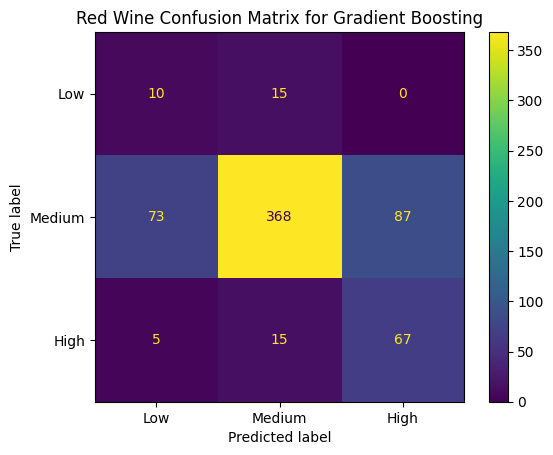

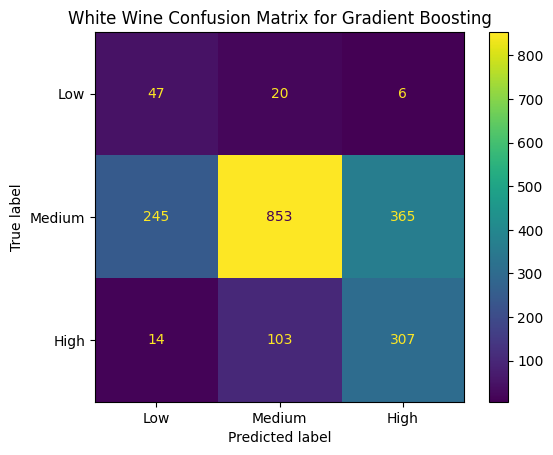

In [ ]:
# ----- Classification Modeling -----
## ----- Stronger Model: Gradient Boosting (GB) -----


model = 'Gradient Boosting'
print(f'Evaluating {model}')

# Define cross validator for k-fold
# Ensure correct splits inside GridSearchCV
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Pipelines
red_gb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    #('pca', PCA(n_components=0.95)),
    ('smote', SMOTE(random_state=seed)),
    ('gb', GradientBoostingClassifier(random_state=seed))
])

white_gb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    #('pca', PCA(n_components=0.95)),
    ('smote', SMOTE(random_state=seed)),
    ('gb', GradientBoostingClassifier(random_state=seed))
])

# Parameter grid
gb_param_grid = {
    #'pca__n_components': [0.90, 0.95, 0.99],
    'gb__n_estimators': [300],
    'gb__max_depth': [3],
    'gb__min_samples_split': [2,5,10],
    'gb__learning_rate': [0.01, 0.1]
}

# GridSearchCV
red_gb_grid = GridSearchCV(
    estimator=red_gb_pipe,
    param_grid=gb_param_grid,
    scoring='balanced_accuracy',
    cv=cv,
    refit=True,
    n_jobs=-1
)

white_gb_grid = GridSearchCV(
    estimator=white_gb_pipe,
    param_grid=gb_param_grid,
    scoring='balanced_accuracy',
    cv=cv,
    refit=True,
    n_jobs=-1
)

# Fit best model
# Get best parameters
red_gb_grid.fit(X_red_train, Y_red_train)
white_gb_grid.fit(X_white_train, Y_white_train)

print('Best parameters for red wine: ', red_gb_grid.best_params_)
print('Best parameter score for red wine: ', red_gb_grid.best_score_)

print('Best parameters for white wine: ', white_gb_grid.best_params_)
print('Best parameter score for white wine: ', white_gb_grid.best_score_)

# Predict on the test data
Y_red_test_pred_gb = red_gb_grid.predict(X_red_test)
Y_white_test_pred_gb = white_gb_grid.predict(X_white_test)

# Evaluation
print("\nRed Wine Evaluation:")

acc_red = accuracy_score(Y_red_test, Y_red_test_pred_gb)
balanced_acc_red = balanced_accuracy_score(Y_red_test, Y_red_test_pred_gb)
f1_score_macro_red = f1_score(Y_red_test, Y_red_test_pred_gb, average='macro')
f1_score_weighted_red = f1_score(Y_red_test, Y_red_test_pred_gb, average='weighted')

classification_report_red = classification_report(
    Y_red_test,
    Y_red_test_pred_gb,
    target_names=['Low', 'Medium','High'],
    zero_division=0
    )

print(f'\nModel = {model}')
print('\nAccuracy = ', acc_red)
print('\nBalanced Accuracy = ', balanced_acc_red)
print('\nMacro F1-Score = ', f1_score_macro_red)
print('\nWeighted F1-Score = ', f1_score_weighted_red)

print('\nClassification Report = \n', (classification_report_red))


print("\nWhite Wine Evaluation:")

acc_white = accuracy_score(Y_white_test, Y_white_test_pred_gb)
balanced_acc_white = balanced_accuracy_score(Y_white_test, Y_white_test_pred_gb)
f1_score_macro_white = f1_score(Y_white_test, Y_white_test_pred_gb, average='macro')
f1_score_weighted_white = f1_score(Y_white_test, Y_white_test_pred_gb, average='weighted')

classification_report_white = classification_report(
    Y_white_test,
    Y_white_test_pred_gb,
    target_names=['Low', 'Medium','High'],
    zero_division=0
    )
print(f'\nModel = {model}')
print('\nAccuracy = ', acc_white)
print('\nBalanced Accuracy = ', balanced_acc_white)
print('\nMacro F1-Score = ', f1_score_macro_white)
print('\nWeighted F1-Score = ', f1_score_weighted_white)

print('\nClassification Report = \n', (classification_report_white))

# Confusion Matrices

# Red wine dataset
ConfusionMatrixDisplay.from_predictions(
    Y_red_test,
    Y_red_test_pred_gb,
    display_labels=['Low', 'Medium','High']
)
plt.title(f'Red Wine Confusion Matrix for {model}')
plt.show()

# White wine dataset
ConfusionMatrixDisplay.from_predictions(
    Y_white_test,
    Y_white_test_pred_gb,
    display_labels=['Low', 'Medium','High']
)
plt.title(f'White Wine Confusion Matrix for {model}')
plt.show()

Evaluating XGBoost
Best parameters for red wine:  {'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 100}
Best parameter score for red wine:  0.5953114139735415
Best parameters for white wine:  {'xgb__learning_rate': 0.01, 'xgb__max_depth': 3, 'xgb__n_estimators': 300}
Best parameter score for white wine:  0.6600608281371705

Red Wine Evaluation:

Model = XGBoost

Accuracy =  0.76875

Balanced Accuracy =  0.6138288052943226

Macro F1-Score =  0.5491580767367076

Weighted F1-Score =  0.7893222068617572

Classification Report = 
               precision    recall  f1-score   support

         Low       0.18      0.32      0.23        25
      Medium       0.92      0.80      0.85       528
        High       0.46      0.72      0.56        87

    accuracy                           0.77       640
   macro avg       0.52      0.61      0.55       640
weighted avg       0.83      0.77      0.79       640


White Wine Evaluation:

Model = XGBoost

Accuracy =  0.575

Balan

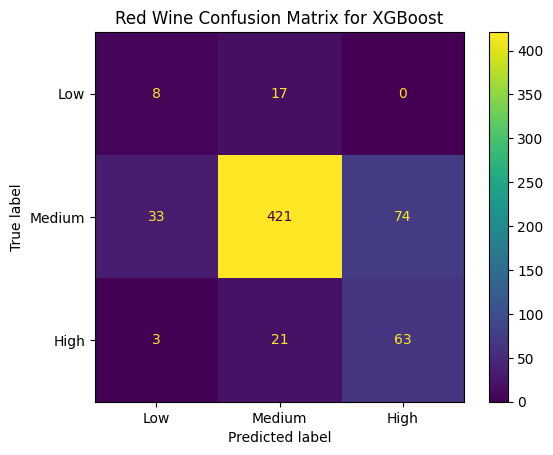

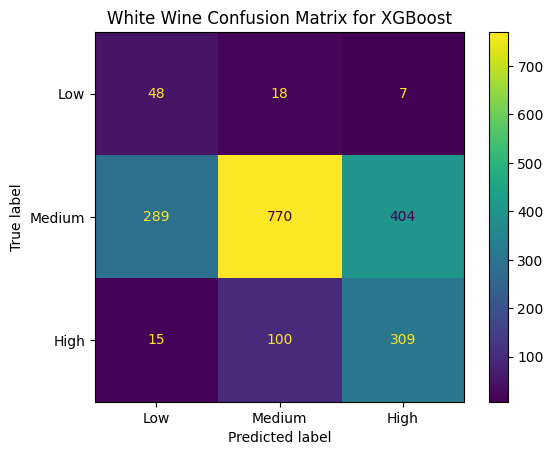

In [ ]:
# ----- Classification Modeling -----
## ----- Stronger Model: XGBoost (XGB) -----


model = 'XGBoost'
print(f'Evaluating {model}')

# Define cross validator for k-fold
# Ensure correct splits inside GridSearchCV
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Pipelines
red_xgb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    #('pca', PCA(n_components=0.95)),
    ('smote', SMOTE(random_state=seed)),
    ('xgb', XGBClassifier(
        objective='multi:softmax',
        num_class=3,
        learning_rate=0.1,
        eval_metric='merror',
        seed=seed
    ))
])

white_xgb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    #('pca', PCA(n_components=0.95)),
    ('smote', SMOTE(random_state=seed)),
    ('xgb', XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        learning_rate=0.1,
        eval_metric='merror',
        seed=seed
    ))
])


# Parameter grid
xgb_param_grid = {
    #'pca__n_components': [0.90, 0.95, 0.99],
    'xgb__n_estimators': [100, 200, 300],
    'xgb__max_depth': [3,5,7],
    'xgb__learning_rate': [0.01, 0.1]
}

# GridSearchCV
red_xgb_grid = GridSearchCV(
    estimator=red_xgb_pipe,
    param_grid=xgb_param_grid,
    scoring='balanced_accuracy',
    cv=cv,
    refit=True,
    n_jobs=-1
)

white_xgb_grid = GridSearchCV(
    estimator=white_xgb_pipe,
    param_grid=xgb_param_grid,
    scoring='balanced_accuracy',
    cv=cv,
    refit=True,
    n_jobs=-1
)

# Fit best model
# Get best parameters
red_xgb_grid.fit(X_red_train, Y_red_train)
white_xgb_grid.fit(X_white_train, Y_white_train)

print('Best parameters for red wine: ', red_xgb_grid.best_params_)
print('Best parameter score for red wine: ', red_xgb_grid.best_score_)

print('Best parameters for white wine: ', white_xgb_grid.best_params_)
print('Best parameter score for white wine: ', white_xgb_grid.best_score_)

# Predict on the test data
Y_red_test_pred_xgb = red_xgb_grid.predict(X_red_test)
Y_white_test_pred_xgb = white_xgb_grid.predict(X_white_test)

# Evaluation
print("\nRed Wine Evaluation:")

acc_red = accuracy_score(Y_red_test, Y_red_test_pred_xgb)
balanced_acc_red = balanced_accuracy_score(Y_red_test, Y_red_test_pred_xgb)
f1_score_macro_red = f1_score(Y_red_test, Y_red_test_pred_xgb, average='macro')
f1_score_weighted_red = f1_score(Y_red_test, Y_red_test_pred_xgb, average='weighted')

classification_report_red = classification_report(
    Y_red_test,
    Y_red_test_pred_xgb,
    target_names=['Low', 'Medium','High'],
    zero_division=0
    )

print(f'\nModel = {model}')
print('\nAccuracy = ', acc_red)
print('\nBalanced Accuracy = ', balanced_acc_red)
print('\nMacro F1-Score = ', f1_score_macro_red)
print('\nWeighted F1-Score = ', f1_score_weighted_red)

print('\nClassification Report = \n', (classification_report_red))


print("\nWhite Wine Evaluation:")

acc_white = accuracy_score(Y_white_test, Y_white_test_pred_xgb)
balanced_acc_white = balanced_accuracy_score(Y_white_test, Y_white_test_pred_xgb)
f1_score_macro_white = f1_score(Y_white_test, Y_white_test_pred_xgb, average='macro')
f1_score_weighted_white = f1_score(Y_white_test, Y_white_test_pred_xgb, average='weighted')

classification_report_white = classification_report(
    Y_white_test,
    Y_white_test_pred_xgb,
    target_names=['Low', 'Medium','High'],
    zero_division=0
    )
print(f'\nModel = {model}')
print('\nAccuracy = ', acc_white)
print('\nBalanced Accuracy = ', balanced_acc_white)
print('\nMacro F1-Score = ', f1_score_macro_white)
print('\nWeighted F1-Score = ', f1_score_weighted_white)

print('\nClassification Report = \n', (classification_report_white))

# Confusion Matrices

# Red wine dataset
ConfusionMatrixDisplay.from_predictions(
    Y_red_test,
    Y_red_test_pred_xgb,
    display_labels=['Low', 'Medium','High']
)
plt.title(f'Red Wine Confusion Matrix for {model}')
plt.show()

# White wine dataset
ConfusionMatrixDisplay.from_predictions(
    Y_white_test,
    Y_white_test_pred_xgb,
    display_labels=['Low', 'Medium','High']
)
plt.title(f'White Wine Confusion Matrix for {model}')
plt.show()

In [ ]:
# Resource used:
# https://www.geeksforgeeks.org/machine-learning/feature-importance-in-pca-analyzing-loadings-and-biplots/
# https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html
# https://xgboost.readthedocs.io/en/release_3.2.0/tutorials/model.html
# https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
# https://www.geeksforgeeks.org/machine-learning/understanding-logistic-regression/?cs=1&hl=en-US&biw=1920&bih=945